# 04 — Interpretability: SHAP + Analyst README

**Goal:** explain the champion LightGBM model in language a credit risk analyst (not an ML engineer) can act on.

Outputs:
1. Global SHAP — bar chart of mean(|SHAP|), beeswarm.
2. Dependence plots for the top 5 drivers.
3. Three local explanations: a safe applicant, a risky applicant, a borderline applicant.
4. `outputs/MODEL_README.md` — risk-factor narrative, metric explanations, monitoring guidance.

In [1]:
import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.utils import OUTPUTS_DIR, RANDOM_STATE

pd.set_option("display.max_columns", 50)

## 1. Load model + features + OOF predictions

In [2]:
artifacts = joblib.load(OUTPUTS_DIR / "champion.joblib")
model = artifacts["model"]
calibrator = artifacts["calibrator"]
feature_names = artifacts["feature_names"]
cat_cols = artifacts["categorical_features"]

features = pd.read_parquet(OUTPUTS_DIR / "features.parquet")
X = features[feature_names]
y = features["TARGET"].astype(int)
oof = pd.read_parquet(OUTPUTS_DIR / "oof_predictions.parquet")
print(f"Model loaded: {model.num_trees()} trees, {len(feature_names)} features")
print(f"OOF PD stats: mean={oof['oof_pd'].mean():.4f}, median={oof['oof_pd'].median():.4f}")

Model loaded: 248 trees, 239 features
OOF PD stats: mean=0.0807, median=0.0467


## 2. SHAP global explanation

Computing SHAP on the full 307K rows is slow and overkill. A stratified 20K-row sample gives statistically identical global rankings in ~30s.

In [3]:
rng = np.random.default_rng(RANDOM_STATE)
sample_size = 20_000
pos_idx = np.where(y == 1)[0]
neg_idx = np.where(y == 0)[0]
n_pos = int(sample_size * y.mean())
n_neg = sample_size - n_pos
sample_idx = np.concatenate([
    rng.choice(pos_idx, size=n_pos, replace=False),
    rng.choice(neg_idx, size=n_neg, replace=False),
])
rng.shuffle(sample_idx)
X_sample = X.iloc[sample_idx].reset_index(drop=True)
print(f"Sample: {len(X_sample):,} rows  (default rate: {y.iloc[sample_idx].mean():.4f})")

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)
if isinstance(shap_values, list):
    shap_values = shap_values[1]  # positive class for older shap versions
print(f"SHAP values shape: {shap_values.shape}")

Sample: 20,000 rows  (default rate: 0.0807)


SHAP values shape: (20000, 239)


C:\Users\khera\AppData\Roaming\Python\Python314\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


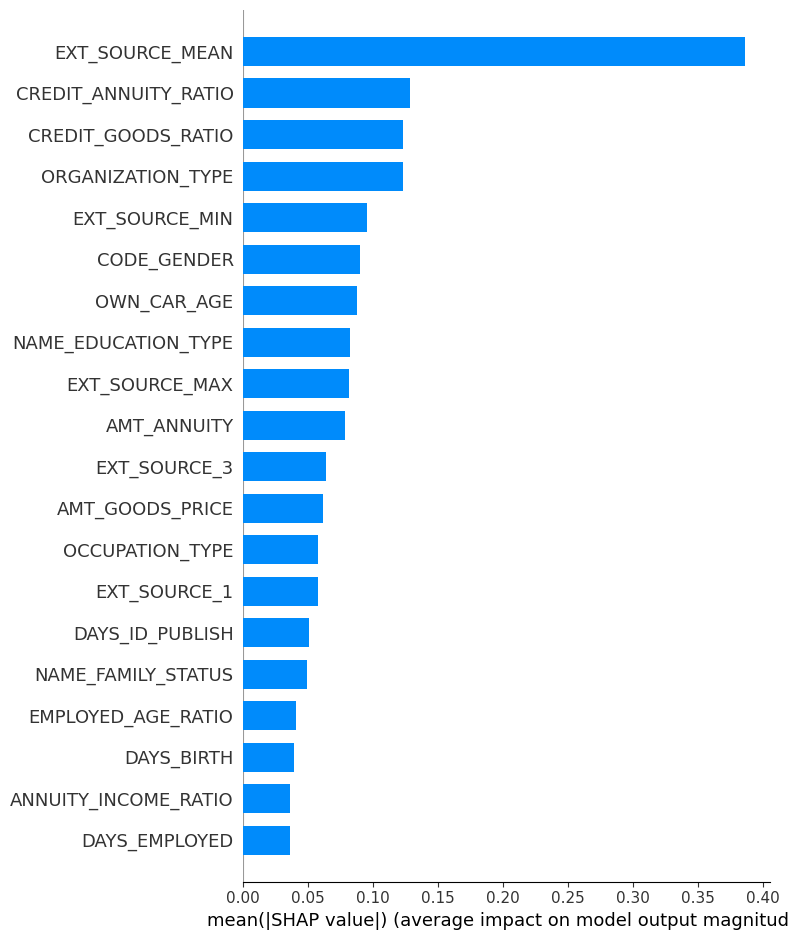

In [4]:
# Global bar chart
plt.figure(figsize=(8, 8))
shap.summary_plot(shap_values, X_sample, plot_type="bar", max_display=20, show=False)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "shap_global_bar.png", dpi=120, bbox_inches="tight")
plt.show()

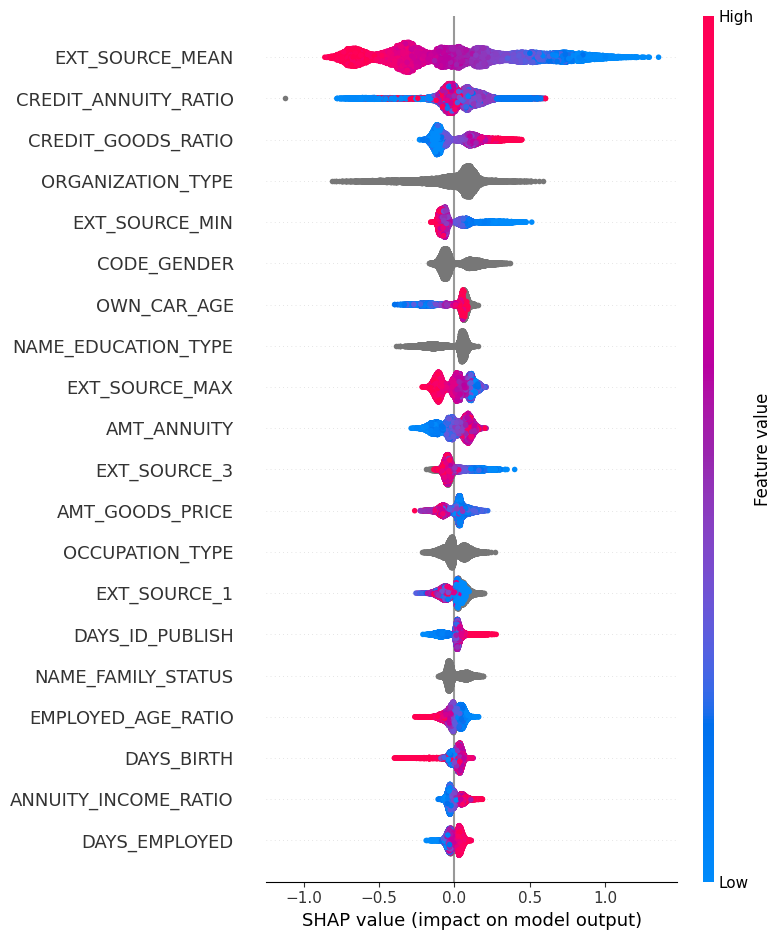

In [5]:
# Beeswarm — shows distribution AND direction
plt.figure(figsize=(8, 8))
shap.summary_plot(shap_values, X_sample, max_display=20, show=False)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "shap_global_beeswarm.png", dpi=120, bbox_inches="tight")
plt.show()

## 3. Top features + dependence plots

For the top 5 drivers we plot how the SHAP contribution varies with the feature value. Red/blue coloring on a second feature shows interaction effects.

In [6]:
mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_names).sort_values(ascending=False)
top5 = mean_abs_shap.head(5)
print("Top 5 SHAP drivers (mean |SHAP|):")
print(top5.round(4))

Top 5 SHAP drivers (mean |SHAP|):
EXT_SOURCE_MEAN         0.3861
CREDIT_ANNUITY_RATIO    0.1285
CREDIT_GOODS_RATIO      0.1230
ORGANIZATION_TYPE       0.1226
EXT_SOURCE_MIN          0.0954
dtype: float64


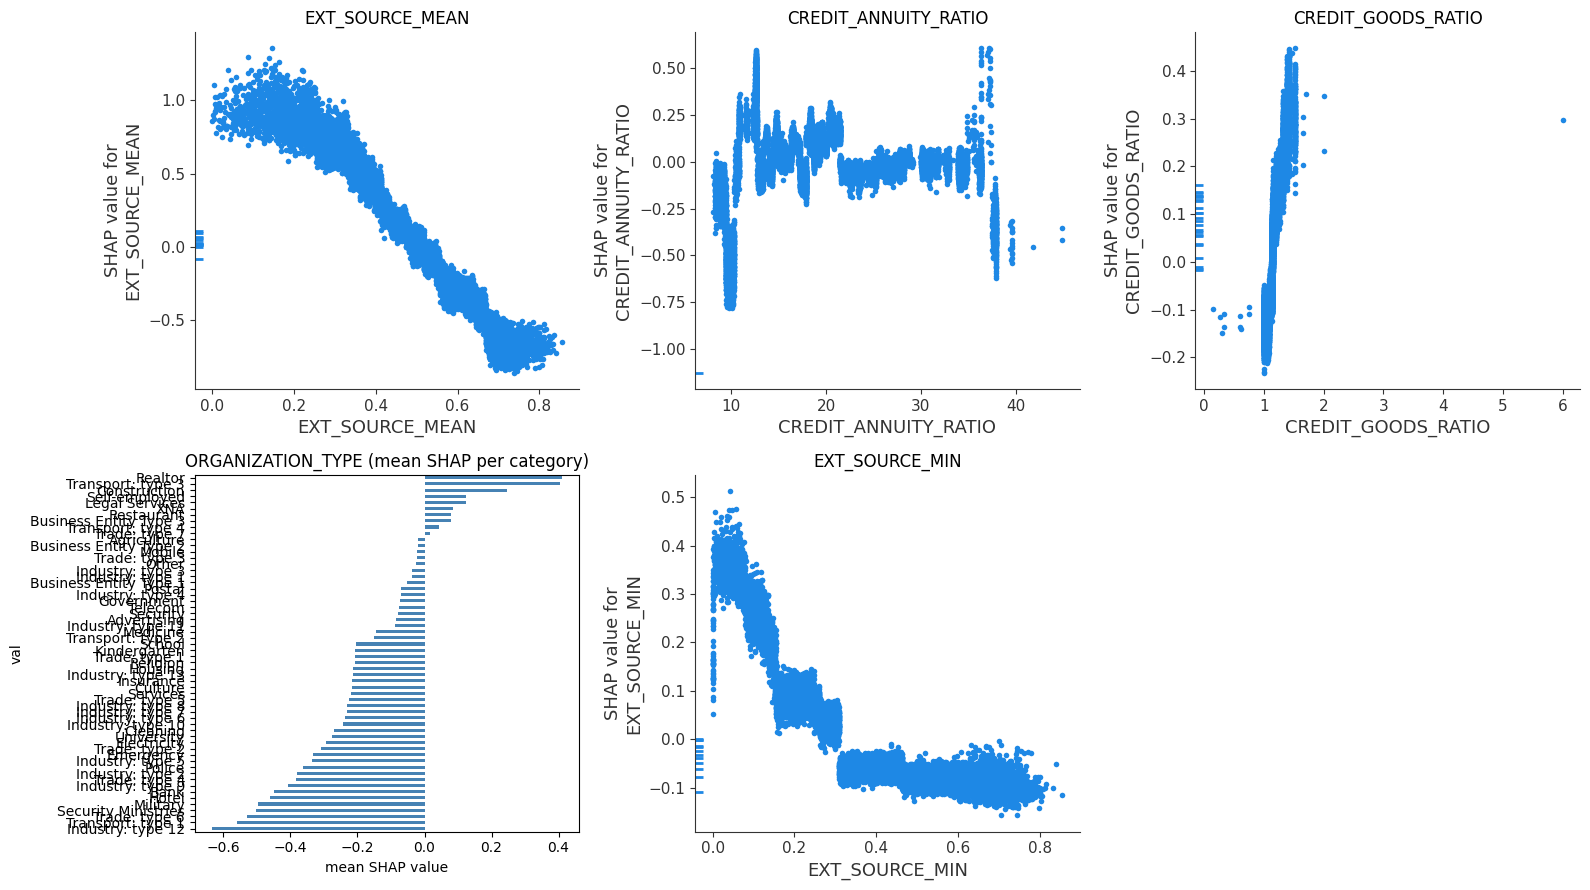

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for ax, feat in zip(axes, top5.index):
    if X_sample[feat].dtype.name == "category":
        # SHAP dependence on categorical: show mean shap per category
        s = pd.DataFrame({"val": X_sample[feat], "shap": shap_values[:, X_sample.columns.get_loc(feat)]})
        order = s.groupby("val", observed=True)["shap"].mean().sort_values()
        order.plot.barh(ax=ax, color="steelblue")
        ax.set_title(f"{feat} (mean SHAP per category)")
        ax.set_xlabel("mean SHAP value")
    else:
        shap.dependence_plot(
            feat, shap_values, X_sample, ax=ax, show=False, interaction_index=None
        )
        ax.set_title(feat)
axes[-1].axis("off")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "shap_dependence_top5.png", dpi=120, bbox_inches="tight")
plt.show()

## 4. Local explanations: safe, risky, borderline

Pick three applicants with very different PDs and decompose each prediction with a SHAP waterfall.

In [8]:
sample_oof = oof.iloc[sample_idx].reset_index(drop=True)
safe_i = sample_oof["oof_pd"].idxmin()
risky_i = sample_oof["oof_pd"].idxmax()
borderline_i = (sample_oof["oof_pd"] - 0.10).abs().idxmin()

for label, i in [("safe", safe_i), ("risky", risky_i), ("borderline (~10%)", borderline_i)]:
    row = sample_oof.iloc[i]
    print(f"{label:<22s} idx={i:>5d}  SK_ID_CURR={int(row['SK_ID_CURR'])}  actual={int(row['TARGET'])}  PD={row['oof_pd']:.4f}")

safe                   idx= 3611  SK_ID_CURR=396459  actual=0  PD=0.0000
risky                  idx= 4726  SK_ID_CURR=157248  actual=1  PD=1.0000
borderline (~10%)      idx= 1201  SK_ID_CURR=326274  actual=0  PD=0.0999


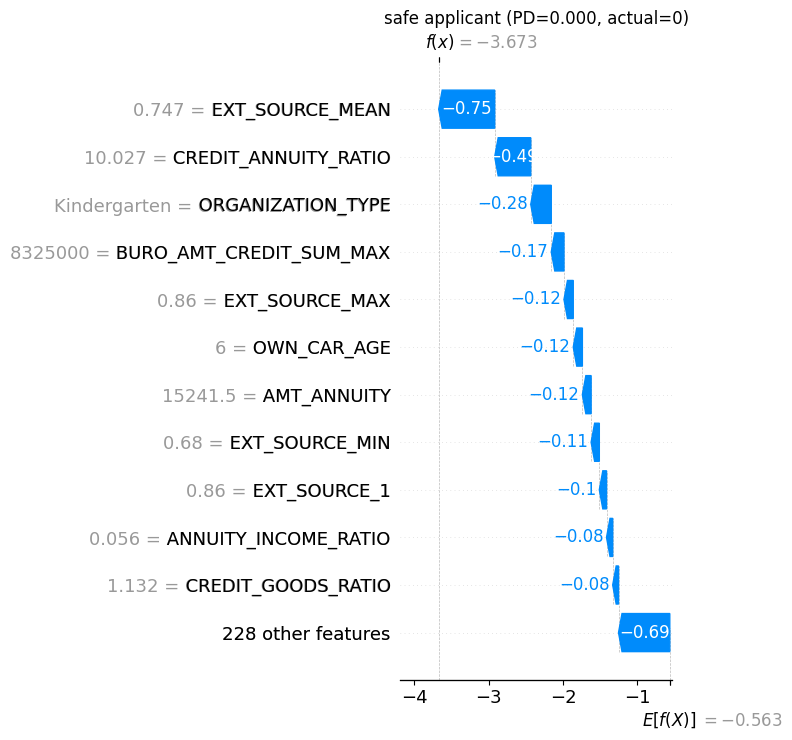

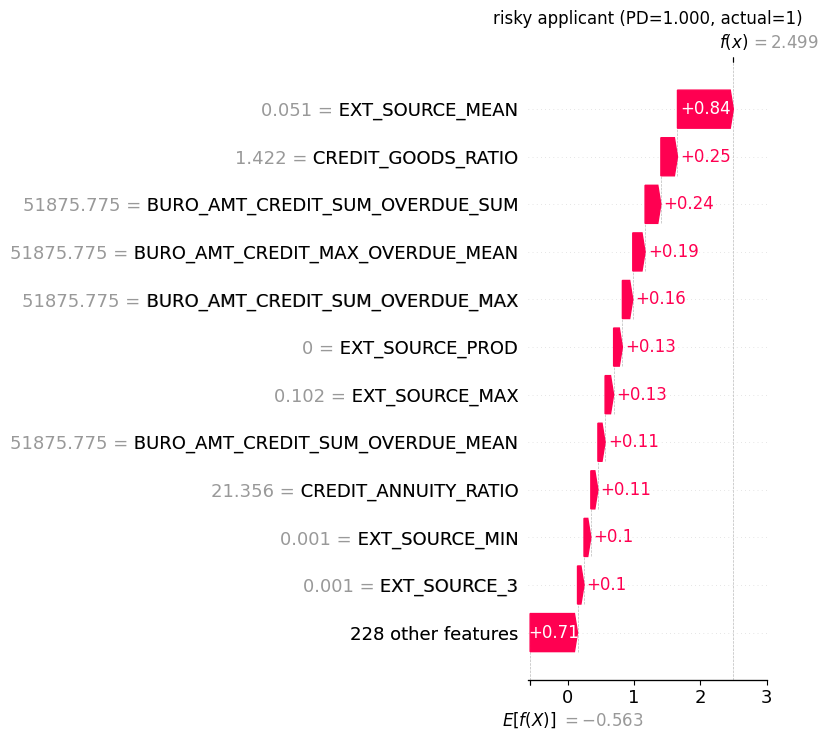

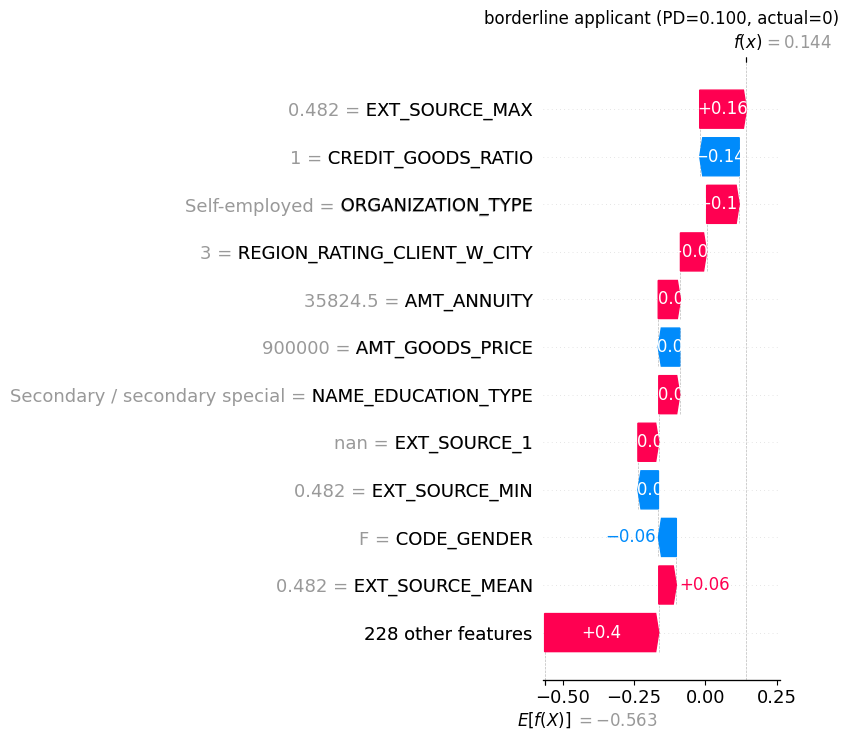

In [9]:
base_value = explainer.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = np.array(base_value).flatten()[-1]

for label, i, fname in [
    ("safe", safe_i, "shap_local_safe.png"),
    ("risky", risky_i, "shap_local_risky.png"),
    ("borderline", borderline_i, "shap_local_borderline.png"),
]:
    expl = shap.Explanation(
        values=shap_values[i],
        base_values=base_value,
        data=X_sample.iloc[i].values,
        feature_names=feature_names,
    )
    plt.figure()
    shap.plots.waterfall(expl, max_display=12, show=False)
    plt.title(f"{label} applicant (PD={sample_oof.iloc[i]['oof_pd']:.3f}, actual={int(sample_oof.iloc[i]['TARGET'])})")
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / fname, dpi=120, bbox_inches="tight")
    plt.show()

## 5. Save top-feature table for the README

In [10]:
top20_shap = mean_abs_shap.head(20).reset_index()
top20_shap.columns = ["feature", "mean_abs_shap"]
top20_shap.to_csv(OUTPUTS_DIR / "shap_top20.csv", index=False)
print(top20_shap.round(4).to_string(index=False))

             feature  mean_abs_shap
     EXT_SOURCE_MEAN         0.3861
CREDIT_ANNUITY_RATIO         0.1285
  CREDIT_GOODS_RATIO         0.1230
   ORGANIZATION_TYPE         0.1226
      EXT_SOURCE_MIN         0.0954
         CODE_GENDER         0.0897
         OWN_CAR_AGE         0.0876
 NAME_EDUCATION_TYPE         0.0824
      EXT_SOURCE_MAX         0.0813
         AMT_ANNUITY         0.0785
        EXT_SOURCE_3         0.0637
     AMT_GOODS_PRICE         0.0612
     OCCUPATION_TYPE         0.0577
        EXT_SOURCE_1         0.0574
     DAYS_ID_PUBLISH         0.0506
  NAME_FAMILY_STATUS         0.0489
  EMPLOYED_AGE_RATIO         0.0405
          DAYS_BIRTH         0.0388
ANNUITY_INCOME_RATIO         0.0359
       DAYS_EMPLOYED         0.0356
